### **ICESat数据处理**

In [1]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
from pyrsimg import readTiff, imgShow, second_to_dyr


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [48]:
path_glah14 = 'data/icesat/GLAH14_634_2125_001_1317_0_01_0001.H5'
path_rsimg = 'data/rsimg/setp_glacier_20200510_wgs84.tif'


In [49]:
!h5ls $path_glah14/Data_1HZ
# !h5ls $path_glah14/Data_1HZ/Geolocation/i_track
# !h5ls $path_glah14/Data_40HZ/Elevation_Surfaces


Atmosphere               Group
DS_UTCTime_1             Dataset {26321/Inf}
Elevation_Flags          Group
Geolocation              Group
Packet_data              Group
Quality                  Group
Reflectivity             Group
Time                     Group
Transmit_Energy          Group


In [97]:
setp_glah14 = h5py.File(path_glah14,'r')
vars_glah14 = {}
vars_glah14['lat'] = setp_glah14['Data_40HZ/Geolocation/d_lat'][:]
vars_glah14['lon'] = setp_glah14['Data_40HZ/Geolocation/d_lon'][:]
vars_glah14['time'] = setp_glah14['Data_40HZ/Time/d_UTCTime_40'][:]
vars_glah14['elev'] = setp_glah14['Data_40HZ/Elevation_Surfaces/d_elev'][:]
### saturation correction
vars_glah14['satu_corr'] = setp_glah14['Data_40HZ/Elevation_Corrections/d_satElevCorr'][:]
vars_glah14['satu_flag'] = setp_glah14['Data_40HZ/Quality/sat_corr_flg'][:]
### data filtering
vars_glah14['elev_flg'] = setp_glah14['Data_40HZ/Quality/elev_use_flg'][:]
vars_glah14['att_flg'] = setp_glah14['Data_40HZ/Quality/sigma_att_flg'][:]
### Delta Ellipsoid (T/P ellipsoid - wgs84 ellipsoid), the glah14 elevation is T/P ellipsoid-based.
vars_glah14['delta_ellip'] = setp_glah14['Data_40HZ/Geophysical/d_deltaEllip'][:]
### srtm dem elevation
vars_glah14['elev_dem'] = setp_glah14['Data_40HZ/Geophysical/d_DEM_elv'][:]
print(vars_glah14['lat'].shape)

## 2. remote sensing image
rsimg = readTiff(path_rsimg)


(1052840,)


### Remove outlier values

In [86]:
invalid_value = 1.7976931348623157e+308
ids = np.where((vars_glah14['lat'] != invalid_value) \
                  & (vars_glah14['lon'] != invalid_value) \
                  & (vars_glah14['elev'] != invalid_value))[0]
for key in vars_glah14:
  vars_glah14[key] = vars_glah14[key][ids]
print(vars_glah14['lat'].shape)


(928596,)


### Filter out low-quality data

In [87]:
ids = np.where((vars_glah14['elev_flg']==0) & vars_glah14['att_flg'] == 0)[0]
for key in vars_glah14:
  vars_glah14[key] = vars_glah14[key][ids]
print(vars_glah14['lat'].shape)


(928596,)


### apply corrections

In [88]:
### Apply saturation correction
ids = np.where(vars_glah14['satu_flag']<2)[0]
for key in vars_glah14:
  vars_glah14[key] = vars_glah14[key][ids]
print(vars_glah14['lat'].shape)
vars_glah14['elev'] += vars_glah14['satu_corr']


(837665,)


In [ ]:
### Apply conversion from T/P ellipsoid to WGS84
vars_glah14['elev'] = vars_glah14['elev'] - vars_glah14['delta_ellip']


### Time conversion

In [101]:
### Apply time conversion (seconds to decimal year)
vars_glah14['time'] = second_to_dyr(vars_glah14['time'])
vars_glah14['time']


array([2008.76330755, 2008.76330755, 2008.76330755, ..., 2008.76580369,
       2008.76580369, 2008.76580369])

In [89]:
### select the data for the specific region
ids = np.where((vars_glah14['lat']>28.86) & (vars_glah14['lat']<29.45) \
                        & (vars_glah14['lon'] >98) & (vars_glah14['lon']<98.69))
for key in vars_glah14:
  vars_glah14[key] = vars_glah14[key][ids]
print(vars_glah14['lat'].shape)


(120,)


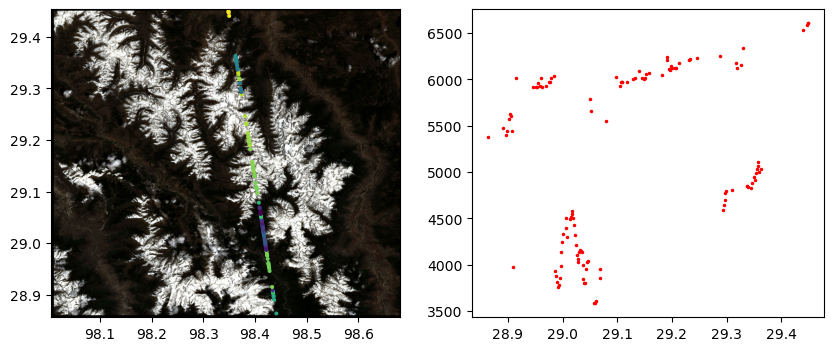

In [95]:
fig, ax = plt.subplots(1,2, figsize=(10, 4))
imgShow(rsimg.array, extent=rsimg.geoextent, clip_percent=5, ax=ax[0])
ax[0].scatter(x=vars_glah14['lon'], y=vars_glah14['lat'], c=vars_glah14['elev'], s=3.5)  ## jason data
ax[1].plot(vars_glah14['lat'], vars_glah14['elev'], 'r.', markersize = 3)



-500.517